In [ ]:
!python -m pip install uv -q
!uv pip install "git+https://github.com/leejunsu0530/basic_computing_final_project" yt-dlp[deno]  -q 


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from yt_analysis.utils import read_json
from pathlib import Path
from yt_analysis.simple_ydl_downloader import YdlDownloader
from yt_analysis.utils import download_zip
from yt_analysis.codes_from_class import check_positive, generate_wordcloud
from rich.pretty import pprint
# from yt_analysis import console
from rich.console import Console
from rich.markdown import Markdown

console = Console()

json_path = Path('yt_dlp_jsons')
json_path.mkdir(parents=True, exist_ok=True)


In [40]:
# # 데이터 가져오기
# USE_GITHUB_ZIP = True
# if USE_GITHUB_ZIP:
#     # download_zip("https://github.com/leejunsu0530/basic_computing_final_project/raw/main/jsons.zip", json_path)
#     # 1. 파일 다운로드 (wget 사용)
#     !wget -q https://github.com/leejunsu0530/basic_computing_final_project/raw/main/jsons.zip

#     # 2. 압축 해제 (unzip 사용)
#     !unzip -qo jsons.zip -d {str(json_path)}
#     pass

# else: # 직접 다운로드
#     YdlDownloader(
#         "http://www.youtube.com/channel/UCX6OQ3DkcsbYNE6H8uQQuVA",
#         "https://www.tiktok.com/@khaby.lame",
#         playlist_info_json_dir=r"C:\Users\leeju\Projects\basic_computing_final_project\test\.test",
#         video_info_json_dir=r"C:\Users\leeju\Projects\basic_computing_final_project\test\.test\khabylame"
#     ).download_playlist_info(1)

# # json_path = json_path / '.test'


In [41]:
# # 영상 파일들에서 필요한 데이터만 glob으로 가져와 df로 만들기

# mrbeast_jsons = [read_json(p) for p in (json_path / "mrbeast").rglob("*.json")]
# khaby_jsons = [read_json(p) for p in (json_path / "khabylame").rglob("*.json")]

# # 영상 데이터에서 필요한 키와 벨류들을 가져와 df로 만들기
# # 각각의 채널의 각 영상에서, 아래 키들을 가져온다. 만약 해당 키가 없으면 벨류를 None으로 하여 둔다.
# keys = ('id', 'title', 'duration', 'view_count', 'comment_count',
#         'like_count', 'upload_date', 'duration_string', 'aspect_ratio')

# # mrbeast 데이터프레임 생성
# mrbeast_data = [{key: video_info.get(key) for key in keys}
#                 for video_info in mrbeast_jsons]
# df_mrbeast = pd.DataFrame(mrbeast_data)

# # khaby 데이터프레임 생성
# khaby_data = [{key: video_info.get(key) for key in keys}
#               for video_info in khaby_jsons]
# df_khaby = pd.DataFrame(khaby_data)


In [ ]:
# 데이터 가져오기
!wget -q https://github.com/leejunsu0530/basic_computing_final_project/raw/main/df_khaby.csv
!wget -q https://github.com/leejunsu0530/basic_computing_final_project/raw/main/df_mrbeast.csv
!wget -q https://github.com/leejunsu0530/basic_computing_final_project/raw/main/khaby.lame.json
!wget -q https://github.com/leejunsu0530/basic_computing_final_project/raw/main/mrbeast.json



'wget'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.
'wget'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


In [3]:
df_mrbeast = pd.read_csv('df_mrbeast.csv', encoding='utf-8-sig')
df_khaby = pd.read_csv('df_khaby.csv', encoding='utf-8-sig')

In [44]:
print(df_mrbeast.head())


            id                                  title  duration  view_count  \
0  dEOlvTqYUNo   #1 MOST INSANE MAGNET LIFE HACK EVER       308    26314951   
1  r7f0L48dHpc          $1  = One Year of Clean Water        32   171005441   
2  uNu6XEPTy5g                    $1 or Mystery Vial?        34    48807151   
3  iogcY_4xGjo           $1 vs $1,000,000 Hotel Room!       940   444833369   
4  pAnGwRiQ4-4  $1 vs $1,000,000,000 Futuristic Tech!      1383   148743254   

   comment_count  like_count  upload_date duration_string  aspect_ratio  
0        17000.0    519157.0     20170324            5:08          1.78  
1        19000.0   4626567.0     20250802              32          0.56  
2        14000.0   1426176.0     20260407              34          0.56  
3       116000.0   7674183.0     20221022           15:40          1.78  
4        89000.0   3111775.0     20260124           23:03          1.78  


# 분석 목표
- 틱톡과 유튜브의 1위 채널들인 Mrbeast와 Khaby lame의 영상들을 분석한다. 이 둘은 해당 플랫폼의 특징들을 잘 대변하기 때문에, 이를 분석하여, 각 플랫폼에서 사람들에게 선호되는 성향(영상 길이, 영상 제목의 방향성 등)을 비교하고 분석한다

# 평가 기준
- 심층적인 분석
    - 예를 들어, 단순히 영상 제목이 부정적인지 긍정적인지를 비교하는 것에서 끝나는 게 아니라, 왜 이런 결과가 나오는지 가설 세우고 검증. > 높은 점수



1. 둘의 간략한 채널 데이터 비교(구독자 수, 평균 조회수, 채널 운영 기간 등)

--- MrBeast summary ---
subscribers: 497000000
num_videos (in JSON folder): 973
avg_views (available videos): 128333499
estimated_channel_period_days: 5213
--- Khaby summary ---
subscribers: 161900000
num_videos (in JSON folder): 1084
avg_views (available videos): 17816427
estimated_channel_period_days: 2270


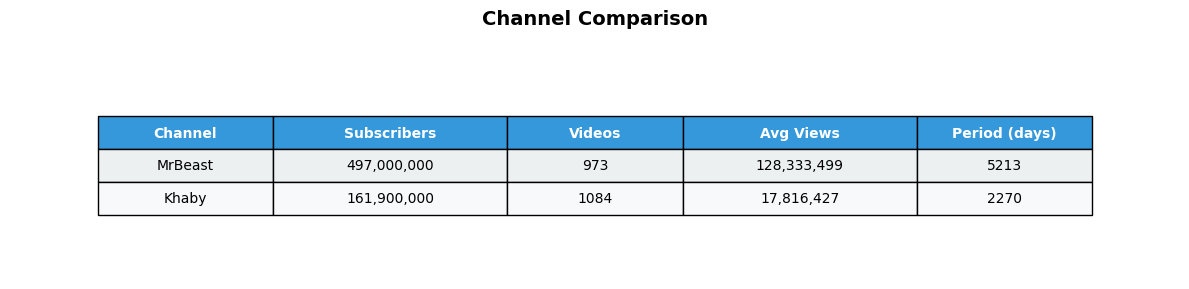

In [5]:
# 1. 둘의 간략한 채널 데이터 비교(구독자 수, 평균 조회수, 채널 운영 기간 등)
console.print(Markdown("# 1. 둘의 간략한 채널 데이터 비교(구독자 수, 평균 조회수, 채널 운영 기간 등)"))

# 채널 정보 JSON 파일 로드 (채널 메타데이터: 구독자 수, 채널명 등)
# mrbeast_channel_info = read_json(json_path / "mrbeast.json")
# khaby_channel_info = read_json(json_path / "khaby.lame.json")
mrbeast_channel_info = read_json("mrbeast.json")
khaby_channel_info = read_json("khaby.lame.json")


def channel_summary(channel_info, df, name="channel"):
    # 구독자 수 추출 (필드명이 다를 수 있으므로 fallback 처리)
    subs = channel_info.get('channel_follower_count') or channel_info.get(
        'channel_subscriber_count')
    if name == 'Khaby': subs = 161900000  # Khaby는 Tiktok 데이터라 구독자 수 직접 입력
    
    # 수집한 영상 개수
    num_videos = len(df)
    
    # 평균 조회수 계산 (NULL 값 제외)
    avg_views = None
    if 'view_count' in df.columns:
        vc = pd.to_numeric(df['view_count'], errors='coerce')  # 숫자로 변환
        if vc.dropna().size:
            avg_views = int(vc.dropna().mean())

    # 채널 운영 기간 계산: 첫 영상과 마지막 영상의 날짜 차이
    channel_period = None
    if 'upload_date' in df.columns and df['upload_date'].notna().any():
        try:
            dates = pd.to_datetime(df['upload_date'].astype(
                str), format='%Y%m%d', errors='coerce')  # 날짜 형식 변환
            if dates.dropna().size:
                # 최신 영상 - 최초 영상의 날짜 차이 (일 단위)
                channel_period = (dates.max() - dates.min()).days
        except Exception:
            channel_period = None

    print(f"--- {name} summary ---")
    print(f"subscribers: {subs}")
    print(f"num_videos (in JSON folder): {num_videos}")
    print(f"avg_views (available videos): {avg_views}")
    print(f"estimated_channel_period_days: {channel_period}")
    
    # 비교를 위한 딕셔너리 반환
    return {
        'Channel': name,
        'Subscribers': f"{subs:,}" if subs else "N/A",
        'Videos': num_videos,
        'Avg Views': f"{avg_views:,}" if avg_views else "N/A",
        'Period (days)': channel_period
    }


# 데이터 수집
channel_data = []
channel_data.append(channel_summary(mrbeast_channel_info, df_mrbeast, name='MrBeast'))
channel_data.append(channel_summary(khaby_channel_info, df_khaby, name='Khaby'))

# 수집된 데이터를 테이블로 시각화
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('tight')
ax.axis('off')

table_df = pd.DataFrame(channel_data)
# 테이블 생성 (셀 크기 조정)
table = ax.table(cellText=table_df.values, colLabels=table_df.columns, 
                cellLoc='center', loc='center', colWidths=[0.15, 0.2, 0.15, 0.2, 0.15])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# 헤더 스타일 (파란색 배경, 흰색 텍스트)
for i in range(len(table_df.columns)):
    table[(0, i)].set_facecolor('#3498db')
    table[(0, i)].set_text_props(weight='bold', color='white')

# 데이터 행 색상 구분 (시각적 구분을 위함)
for i in range(1, len(channel_data) + 1):
    for j in range(len(table_df.columns)):
        if i == 1:
            table[(i, j)].set_facecolor('#ecf0f1')
        else:
            table[(i, j)].set_facecolor('#f8f9fa')

plt.title('Channel Comparison', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


2. 두 채널 운영자의 영상을 각각 업로드 시간-조회수 관계를 두 가지 방식으로 시각화

note: Khaby의 데이터 중 일부는 데이터 다운로드 중 틱톡에 밴을 먹어서 누락됐기 때문에, 가운데 부분이 지워진듯이 
사라져있음.

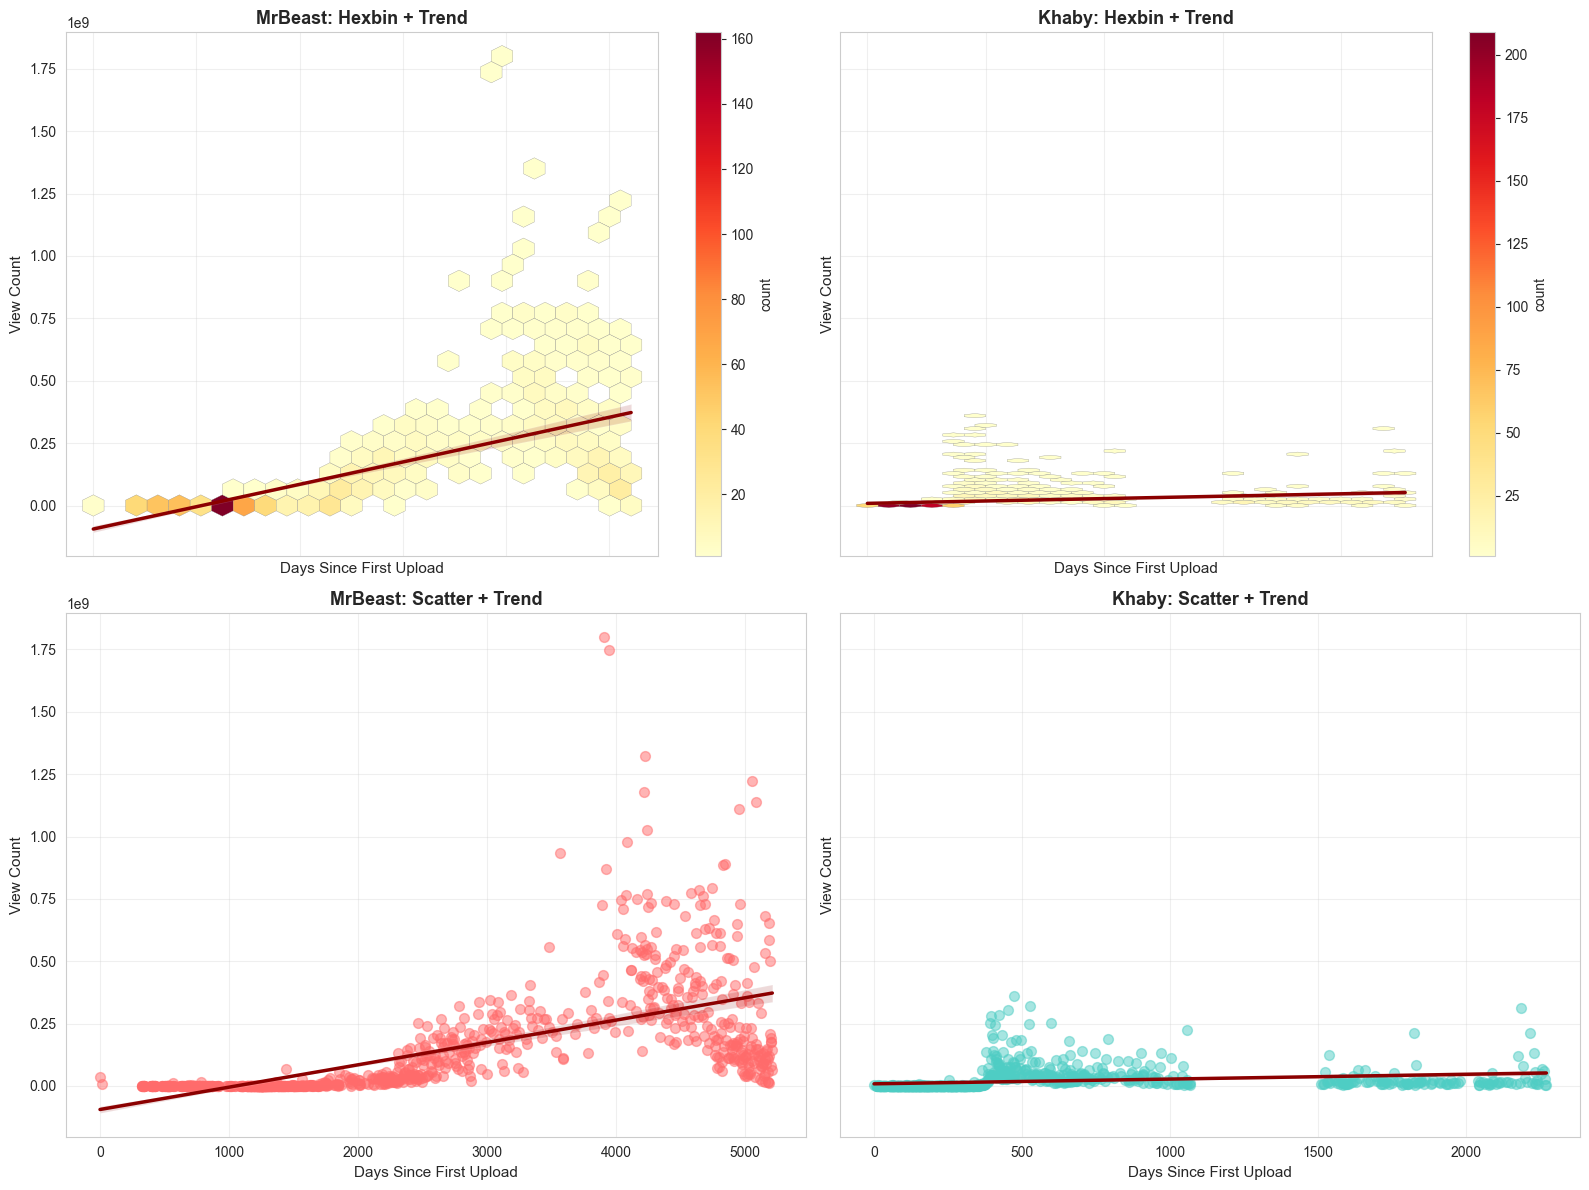

In [6]:
# 2. 두 채널 운영자의 영상을 각각 업로드 시간-조회수 관계를 두 가지 방식으로 시각화
console.print(
    Markdown("# 2. 두 채널 운영자의 영상을 각각 업로드 시간-조회수 관계를 두 가지 방식으로 시각화"))

console.print("note: Khaby의 데이터 중 일부는 데이터 다운로드 중 틱톡에 밴을 먹어서 누락됐기 때문에, 가운데 부분이 지워진듯이 사라져있음.")

# Seaborn 스타일 설정 (전체 그래프의 룩앤필)
sns.set_style("whitegrid")

def prepare_time_vs_views_data(df):
    if 'upload_date' not in df.columns or 'view_count' not in df.columns:
        return pd.DataFrame()

    df_plot = df[['upload_date', 'view_count']].dropna().copy()
    df_plot['upload_date'] = pd.to_datetime(df_plot['upload_date'].astype(str), format='%Y%m%d', errors='coerce')
    df_plot['view_count'] = pd.to_numeric(df_plot['view_count'], errors='coerce')
    df_plot = df_plot.dropna()
    if df_plot.empty:
        return df_plot

    df_plot['days_since_start'] = (df_plot['upload_date'] - df_plot['upload_date'].min()).dt.days
    return df_plot


def plot_time_vs_views(df_plot, ax, title, color, mode='hexbin'):
    if df_plot.empty:
        ax.text(0.5, 0.5, 'data not available', ha='center')
        ax.set_title(title)
        return

    if mode == 'hexbin':
        hb = ax.hexbin(df_plot['days_since_start'], df_plot['view_count'], gridsize=25,
                       cmap='YlOrRd', mincnt=1, edgecolors='grey', linewidths=0.2)
        ax.figure.colorbar(hb, ax=ax, label='count')
        sns.regplot(data=df_plot, x='days_since_start', y='view_count', ax=ax,
                    scatter=False, line_kws={'color': 'darkred', 'linewidth': 2.5})
    else:
        sns.regplot(data=df_plot, x='days_since_start', y='view_count', ax=ax,
                    scatter_kws={'alpha': 0.5, 's': 50, 'color': color},
                    line_kws={'color': 'darkred', 'linewidth': 2.5})

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Days Since First Upload', fontsize=11)
    ax.set_ylabel('View Count', fontsize=11)
    ax.grid(True, alpha=0.3)

# 데이터 준비
mrbeast_plot = prepare_time_vs_views_data(df_mrbeast)
khaby_plot = prepare_time_vs_views_data(df_khaby)

# 2행 2열 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='row')
plot_time_vs_views(mrbeast_plot, axes[0, 0], 'MrBeast: Hexbin + Trend', '#FF6B6B', mode='hexbin')
plot_time_vs_views(khaby_plot, axes[0, 1], 'Khaby: Hexbin + Trend', '#4ECDC4', mode='hexbin')
plot_time_vs_views(mrbeast_plot, axes[1, 0], 'MrBeast: Scatter + Trend', '#FF6B6B', mode='scatter')
plot_time_vs_views(khaby_plot, axes[1, 1], 'Khaby: Scatter + Trend', '#4ECDC4', mode='scatter')

plt.tight_layout()
plt.show()


# 2번 분석
2번에서 알 수 있는 것은, 유튜브의 경우에는 시간이 지나고 연차가 쌓이면서 전반적인 영상의 조회수가 늘어나고, 영상을 자주 올리면 더더욱 그런 경향이 있지만, 틱톡은 그 상승폭이 훨씬 작다는 것이다.

3. 둘의 영상 제목을 각각 워드 클라우드로 나타내기 - 어떠한 단어가 주로 사용되는지 보기 위해

MrBeast - Title Analysis
Top 15 Words:
  the            :  123
  how            :   86
  for            :   84
  you            :   69
  youtube        :   65
  win            :   48
  and            :   42
  world          :   41
  make           :   39
  much           :   38
  money          :   37
  this           :   35
  people         :   34
  does           :   34
  with           :   33

Generating MrBeast wordcloud...


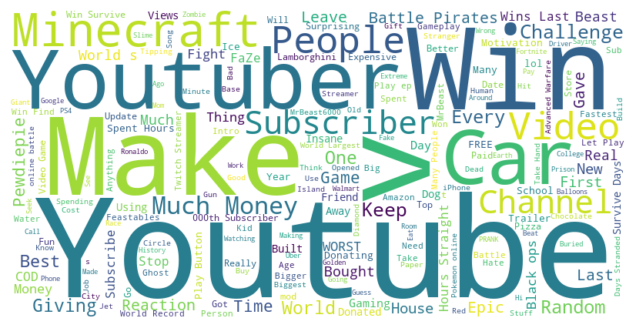


Khaby - Title Analysis
Top 15 Words:
  foryoupage     :  575
  foryou         :  505
  comic          :  299
  learnfromkhaby :  168
  persona        :  165
  dopo           :  161
  comedy         :  130
  ironia         :  106
  con            :  105
  you            :   87
  the            :   87
  tagga          :   77
  nopressure     :   76
  duetto         :   74
  che            :   64

Generating Khaby wordcloud...


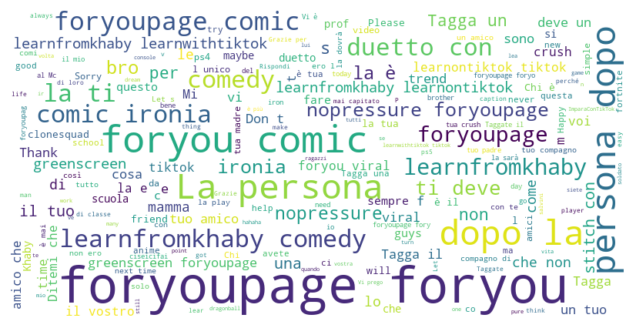

MrBeast titles containing top 5 words:

['the', 'how', 'for', 'you', 'youtube']

$10,000 Every Day You Survive In A Grocery Store

$10,000 Every Day You Survive In The Wilderness

$10,000 Every Day You Survive Prison

...

#distorto #mamma #foryoupage #foryou

#duetto con @4brothersinblue #foryoupage #foryou #coops #viral

#duetto con @abighead #foryou #foryoupage #comic #ritratto

Comparing top words...

C:\Users\leeju\AppData\Local\Temp\ipykernel_4812\2271893090.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_mb, y=words_mb, ax=axes[0], palette='Blues_r', orient='h')
C:\Users\leeju\AppData\Local\Temp\ipykernel_4812\2271893090.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_kb, y=words_kb, ax=axes[1], palette='Reds_r', orient='h')


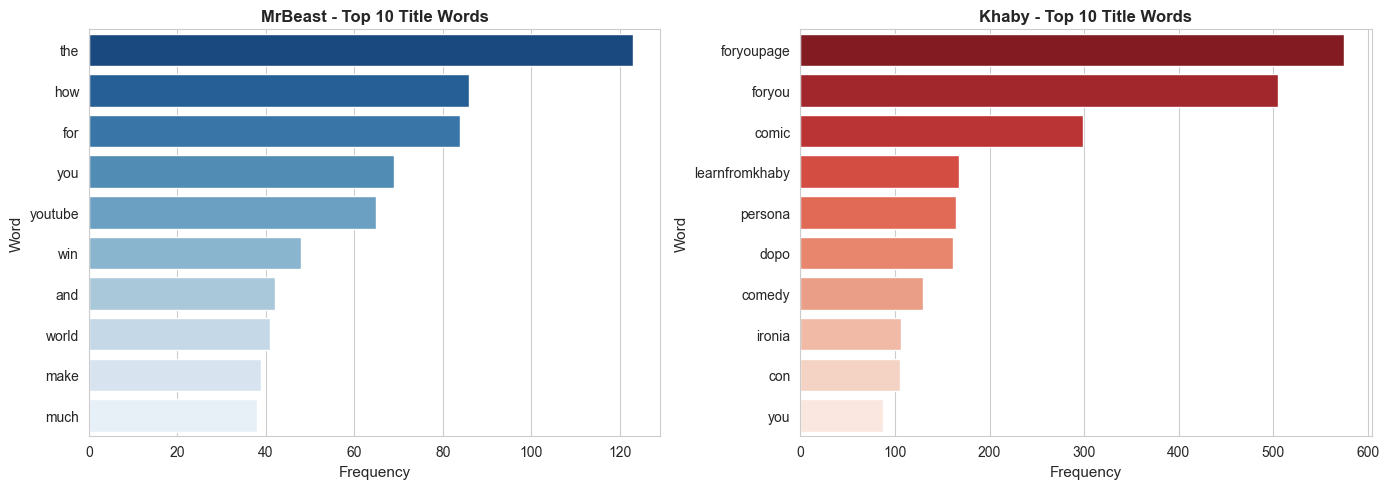

In [7]:
# 3. 둘의 영상 제목을 각각 워드 클라우드로 나타내기 - 어떠한 단어가 주로 사용되는지 보기 위해
console.print(
    Markdown("# 3. 둘의 영상 제목을 각각 워드 클라우드로 나타내기 - 어떠한 단어가 주로 사용되는지 보기 위해"))


def make_title_df_for_wordcloud(df):
    # 제목 컬럼만 추출하고 NaN 제거 후 'text' 컬럼으로 이름 변경
    tmp = df[['title']].dropna().rename(columns={'title': 'text'})
    return tmp

def get_top_words(df, n=15):
    """가장 많이 나온 단어 추출 (단어 빈도 분석)"""
    from collections import Counter
    import re
    
    # 모든 제목을 하나의 문자열로 합침
    text = " ".join(df['title'].dropna().astype(str).tolist())
    # 정규표현식으로 3글자 이상의 단어만 추출 (소문자로 정규화)
    words = re.findall(r'\b[a-z]{3,}\b', text.lower())
    # 단어 빈도 계산 후 상위 n개 반환
    return Counter(words).most_common(n)

# ===== MrBeast 분석 =====
print("=" * 50)
print("MrBeast - Title Analysis")
print("=" * 50)
# MrBeast의 상위 15개 빈도 단어 추출
mb_top_words = get_top_words(df_mrbeast, n=15)
print("Top 15 Words:")
for word, count in mb_top_words:
    print(f"  {word:15s}: {count:4d}")

# MrBeast 워드클라우드 생성 (시각적 단어 빈도 표현)
print("\nGenerating MrBeast wordcloud...")
make_wc_df = make_title_df_for_wordcloud(df_mrbeast)
generate_wordcloud(make_wc_df, text_column='text')

# ===== Khaby 분석 =====
print("\n" + "=" * 50)
print("Khaby - Title Analysis")
print("=" * 50)
# Khaby의 상위 15개 빈도 단어 추출
kb_top_words = get_top_words(df_khaby, n=15)
print("Top 15 Words:")
for word, count in kb_top_words:
    print(f"  {word:15s}: {count:4d}")

# Khaby 워드클라우드 생성
print("\nGenerating Khaby wordcloud...")
make_wc_df = make_title_df_for_wordcloud(df_khaby)
generate_wordcloud(make_wc_df, text_column='text')

# ===== 특정 단어가 들어간 제목 필터링 =====
import re

def filter_titles_by_words(df, words):
    """주어진 단어 리스트 중 하나 이상을 포함하는 제목을 필터링"""
    if 'title' not in df.columns:
        return pd.DataFrame(columns=['title'])
    pattern = '|'.join(re.escape(word.lower()) for word in words)
    mask = df['title'].astype(str).str.lower().str.contains(pattern, na=False)
    return df.loc[mask, ['title']].copy()


def highlight_title_matches(title, words):
    """매칭된 단어들을 노란색 배경으로 강조한 제목을 반환"""
    if title is None:
        return ''
    pattern = re.compile(r'(' + '|'.join(re.escape(word) for word in words) + r')', flags=re.IGNORECASE)
    return pattern.sub(lambda m: f"[on yellow]{m.group(1)}[/]", str(title))

# 예시: 각 채널 상위 단어 일부로 제목 검색
search_words_mb = [w for w, _ in mb_top_words[:5]]
search_words_kb = [w for w, _ in kb_top_words[:5]]

console.print("MrBeast titles containing top 5 words:", style="bold underline")
console.print(search_words_mb)
for title in filter_titles_by_words(df_mrbeast, search_words_mb)['title'].head(10):
    console.print(highlight_title_matches(title, search_words_mb))

console.print("\nKhaby titles containing top 5 words:", style="bold underline")
console.print(search_words_kb)
for title in filter_titles_by_words(df_khaby, search_words_kb)['title'].head(10):
    console.print(highlight_title_matches(title, search_words_kb))

# ===== 상위 단어 비교 그래프 =====
console.print("\nComparing top words...", style="bold")
# 1행 2열 서브플롯: 각 채널의 상위 10개 단어를 막대그래프로 표현
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MrBeast 상위 10개 단어
words_mb = [w[0] for w in mb_top_words[:10]]
counts_mb = [w[1] for w in mb_top_words[:10]]
# 수평 막대그래프로 표현 (단어 이름을 읽기 쉽게)
sns.barplot(x=counts_mb, y=words_mb, ax=axes[0], palette='Blues_r', orient='h')
axes[0].set_title('MrBeast - Top 10 Title Words', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Frequency', fontsize=11)
axes[0].set_ylabel('Word', fontsize=11)

# Khaby 상위 10개 단어
words_kb = [w[0] for w in kb_top_words[:10]]
counts_kb = [w[1] for w in kb_top_words[:10]]
# 두 채널의 색상 구분 (MrBeast: 파랑, Khaby: 빨강)
sns.barplot(x=counts_kb, y=words_kb, ax=axes[1], palette='Reds_r', orient='h')
axes[1].set_title('Khaby - Top 10 Title Words', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Frequency', fontsize=11)
axes[1].set_ylabel('Word', fontsize=11)

plt.tight_layout()
plt.show()


In [8]:
df_mrbeast[df_mrbeast['title'].str.contains('world', case=False, na=False)][['title']].head()

,title
37,10 People Vs World's Deadliest Laser Maze for ...
43,100 Kids Vs World's Strongest Man!
46,100 People Vs World’s Biggest Trap!
58,"2,256 Miles In One Uber Ride (World Record)"
156,Bottle Head Smashing World Record Attempt!


# 3번 분석:
- 유튜브는 워드 클라우드가 또렷하게, 특정 단어들이 큰 비중을 차지하는 것을 보여줄 수 있었지만, 틱톡은 그에 비해 단어들의 크기 편차가 크지 않았다. 이는 틱톡은 특정 단어가 소위 '어그로'를 끄는 겨웅가 적다는 것으로 해석할 수 있다.
- **틱톡**: 틱톡에서 자주 사용되는 단어들을 보면 띄어쓰기가 되어있지 않은 단어 뭉치가 자주 보이는데, 이는 헤시테그가 제목으로 사용되는 틱톡의 특성에서 기인한 것으로 볼 수 있다.
- **유튜브**: 유튜브에서 자주 사용되는 단어들을 분석해보자면, 정관사인 the는 제외하고, how, much, world 등이 있는데, 

4. 둘의 영상 제목들을 부정적인지 여부를 구한 후, 값들을 df에 벨류로 추가하고 그 평균과 중앙값을 내서 그래프에   
                              그리기 - 부정적인 제목이 많은지 긍정적인 제목이 많은지

MrBeast polarity mean: 0.06314062553459814
MrBeast polarity median: 0.0
Khaby polarity mean: 0.09829931014173404
Khaby polarity median: 0.0


C:\Users\leeju\AppData\Local\Temp\ipykernel_4812\1746230885.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_combined_polarity, x='channel', y='title_polarity', ax=ax1,
c:\Users\leeju\Projects\basic_computing_final_project\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 48.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\leeju\Projects\basic_computing_final_project\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 72.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\leeju\Projects\basic_computing_final_project\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 47.0% of the points cannot 

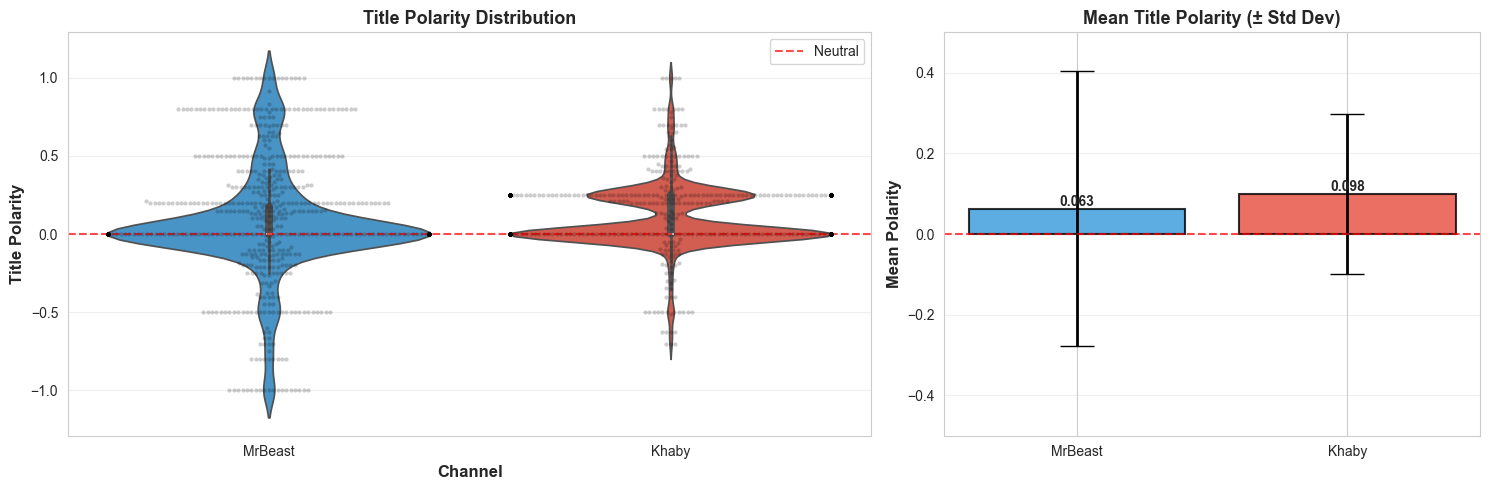

In [9]:
# 4. 둘의 영상 제목들을 부정적인지 여부를 구한 후, 값들을 df에 벨류로 추가하고 그 평균과 중앙값을 내서 그래프에 그리기 - 부정적인 제목이 많은지 긍정적인 제목이 많은지
console.print(Markdown(
    "# 4. 둘의 영상 제목들을 부정적인지 여부를 구한 후, 값들을 df에 벨류로 추가하고 그 평균과 중앙값을 내서 그래프에 그리기 - 부정적인 제목이 많은지 긍정적인 제목이 많은지"))


def add_polarity_column(df):
    """각 제목의 감성 점수 계산 (TextBlob polarity: -1~1)"""
    def polarity_of(text):
        try:
            # TextBlob으로 감성 분석
            blob = check_positive(str(text))
            # 감성점수 추출 (-1: 부정, 0: 중립, 1: 긍정)
            return float(blob.sentiment.polarity)
        except Exception:
            return None

    df = df.copy()
    # 각 제목에 대해 감성점수 계산해 새로운 컬럼 추가
    df['title_polarity'] = df['title'].apply(
        polarity_of) if 'title' in df.columns else None
    return df


# 두 채널 데이터에 감성 점수 컬럼 추가
df_mrbeast = add_polarity_column(df_mrbeast)
df_khaby = add_polarity_column(df_khaby)


def polarity_summary(df, name):
    """감성 점수의 평균과 중앙값 출력"""
    if 'title_polarity' not in df.columns:
        print(name, 'no polarity data')
        return
    # NULL 값 제외하고 숫자로 변환
    vals = pd.to_numeric(df['title_polarity'], errors='coerce').dropna()
    # 평균과 중앙값 계산 (집중화 경향 파악)
    print(f"{name} polarity mean: {vals.mean() if vals.size else None}")
    print(f"{name} polarity median: {vals.median() if vals.size else None}")


polarity_summary(df_mrbeast, 'MrBeast')
polarity_summary(df_khaby, 'Khaby')

# ===== 분포 시각화 (Violin plot + Bar chart) =====
fig = plt.figure(figsize=(15, 5))
# GridSpec으로 레이아웃 설정 (왼쪽 1.5, 오른쪽 1 비율)
gs = fig.add_gridspec(1, 2, width_ratios=[1.5, 1])

# ===== 왼쪽: Violin plot (분포 형태 시각화) =====
ax1 = fig.add_subplot(gs[0])
# 감성점수 데이터 준비
df_mrbeast_plot = df_mrbeast[['title_polarity']].dropna().copy()
df_mrbeast_plot['channel'] = 'MrBeast'
df_khaby_plot = df_khaby[['title_polarity']].dropna().copy()
df_khaby_plot['channel'] = 'Khaby'
# 두 채널 데이터 합침
df_combined_polarity = pd.concat([df_mrbeast_plot, df_khaby_plot], ignore_index=True)

# Violin plot: 데이터 분포의 형태를 곡선으로 표현 (중앙값과 분포의 밀도 한눈에 파악)
sns.violinplot(data=df_combined_polarity, x='channel', y='title_polarity', ax=ax1,
               palette=['#3498db', '#e74c3c'], inner='box')  # inner='box'로 사분위수 표시
# Swarmplot 추가: 개별 데이터 포인트 표시 (샘플 크기, 이상치 확인)
sns.swarmplot(data=df_combined_polarity, x='channel', y='title_polarity', ax=ax1,
              color='black', alpha=0.2, size=3)
ax1.set_ylabel('Title Polarity', fontsize=12, fontweight='bold')
ax1.set_xlabel('Channel', fontsize=12, fontweight='bold')
ax1.set_title('Title Polarity Distribution', fontsize=13, fontweight='bold')
# 중립점 표시 (0)
ax1.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Neutral')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# ===== 오른쪽: Bar chart (평균값 비교) =====
ax2 = fig.add_subplot(gs[1])
channels = ['MrBeast', 'Khaby']
means = []
stds = []

# 각 채널의 평균과 표준편차 계산
for df, name in [(df_mrbeast, 'MrBeast'), (df_khaby, 'Khaby')]:
    vals = pd.to_numeric(df['title_polarity'], errors='coerce').dropna()
    if vals.size:
        means.append(vals.mean())
        stds.append(vals.std())  # 표준편차: 변동성 크기
    else:
        means.append(0)
        stds.append(0)

# 막대그래프 + 에러바 (평균 ± 표준편차)
colors = ['#3498db', '#e74c3c']
bars = ax2.bar(channels, means, yerr=stds, capsize=12, alpha=0.8, color=colors, 
               edgecolor='black', linewidth=1.5, error_kw={'linewidth': 2})

# 평균값을 막대 위에 라벨로 표시 (정확한 값 확인)
for bar, mean in zip(bars, means):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{mean:.3f}', ha='center', va='bottom', fontweight='bold')

ax2.set_ylabel('Mean Polarity', fontsize=12, fontweight='bold')
ax2.set_title('Mean Title Polarity (± Std Dev)', fontsize=13, fontweight='bold')
# 중립점 표시
ax2.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.set_ylim([-0.5, 0.5])
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


5. 두 채널 운영자의 각 영상 제목의 긍정/부정치와 조회수의 상관관계를 두 가지 방식으로 시각화

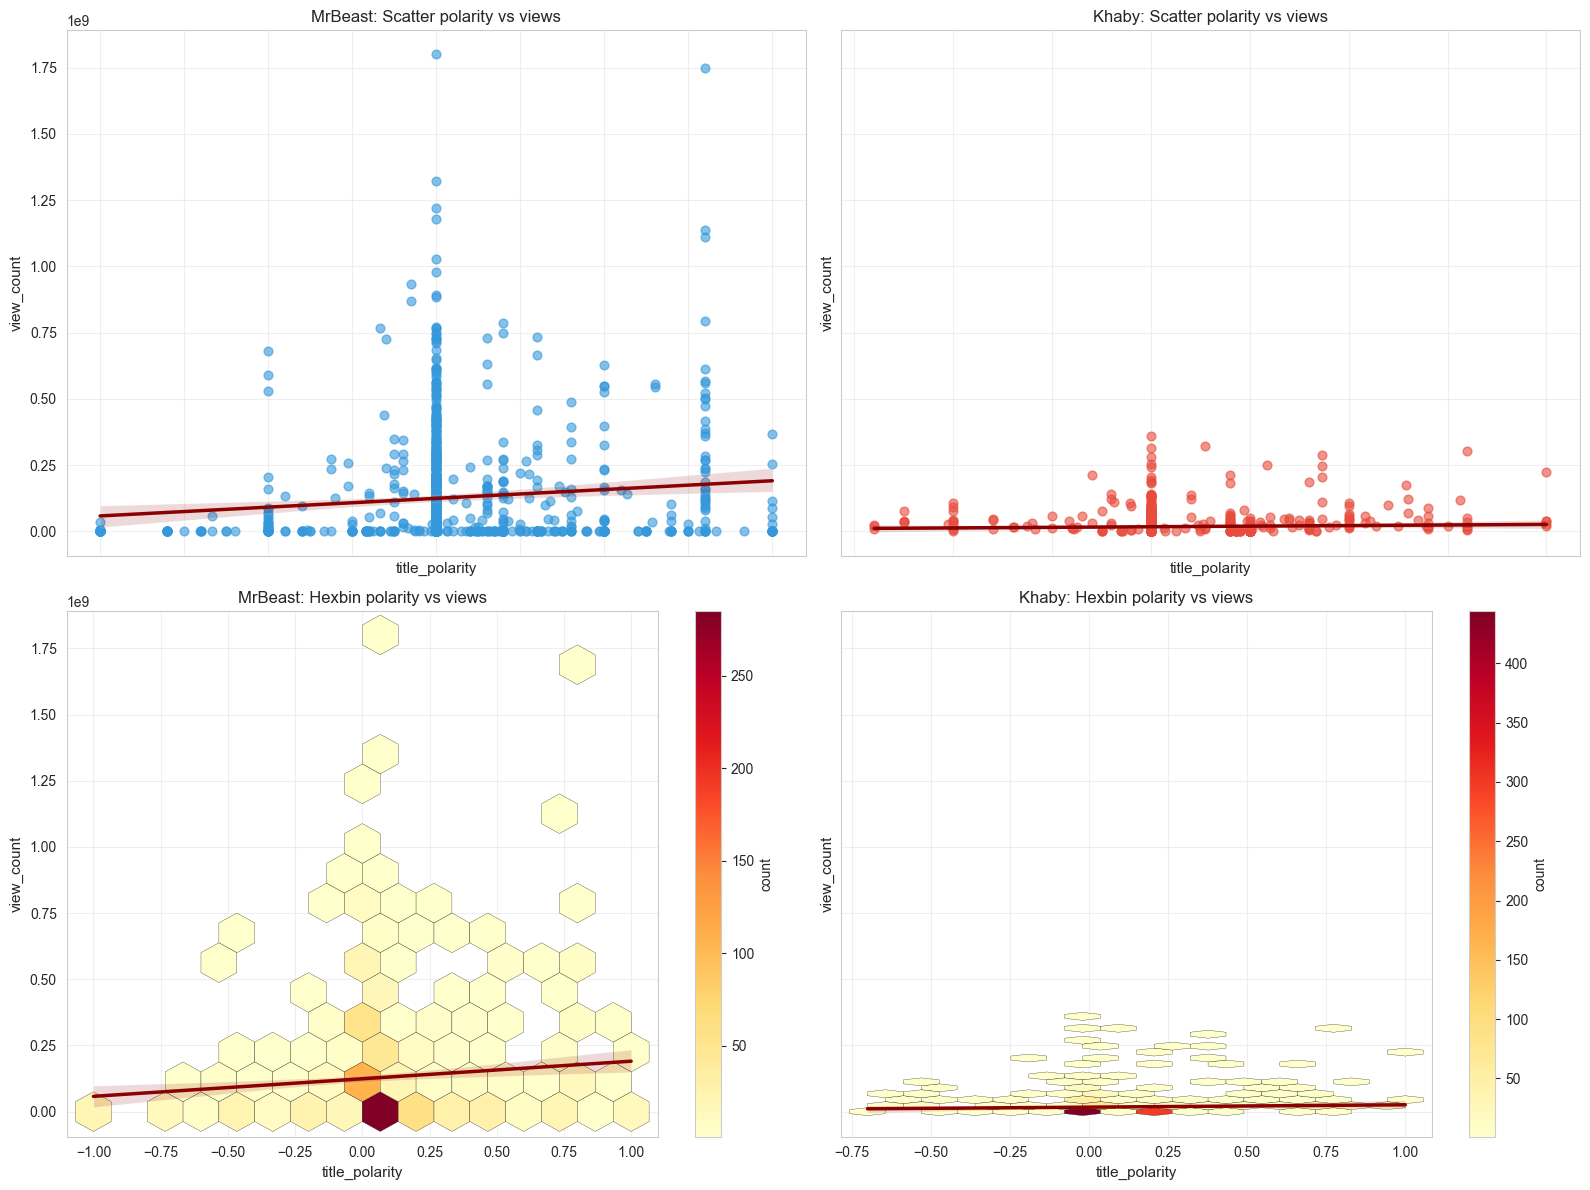

In [16]:
# 5. 두 채널 운영자의 각 영상 제목의 긍정/부정치와 조회수의 상관관계를 두 가지 방식으로 시각화
console.print(Markdown(
    "# 5. 두 채널 운영자의 각 영상 제목의 긍정/부정치와 조회수의 상관관계를 두 가지 방식으로 시각화"))


def plot_polarity_vs_views(df, ax, title, mode='scatter', color='#3b6b9c'):
    if 'title_polarity' not in df.columns or 'view_count' not in df.columns:
        ax.text(0.5, 0.5, 'data not available', ha='center')
        ax.set_title(title)
        return

    x = pd.to_numeric(df['title_polarity'], errors='coerce')
    y = pd.to_numeric(df['view_count'], errors='coerce')
    mask = x.notna() & y.notna()
    if not mask.any():
        ax.text(0.5, 0.5, 'no valid data', ha='center')
        ax.set_title(title)
        return

    if mode == 'hexbin':
        hb = ax.hexbin(x[mask], y[mask], gridsize=15, cmap='YlOrRd', mincnt=1,
                       edgecolors='black', linewidths=0.2)
        plt.colorbar(hb, ax=ax, label='count')
        sns.regplot(data=df.loc[mask], x='title_polarity', y='view_count', ax=ax,
                    scatter=False, line_kws={'color': 'darkred', 'linewidth': 2.5})
    else:
        sns.regplot(data=df.loc[mask], x='title_polarity', y='view_count', ax=ax,
                    scatter_kws={'alpha': 0.6, 's': 40, 'color': color},
                    line_kws={'color': 'darkred', 'linewidth': 2.5})

    ax.set_xlabel('title_polarity', fontsize=11)
    ax.set_ylabel('view_count', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.3)


# 2행 2열 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='row')
plot_polarity_vs_views(df_mrbeast, axes[0, 0], 'MrBeast: Scatter polarity vs views', mode='scatter', color='#3498db')
plot_polarity_vs_views(df_khaby, axes[0, 1], 'Khaby: Scatter polarity vs views', mode='scatter', color='#e74c3c')
plot_polarity_vs_views(df_mrbeast, axes[1, 0], 'MrBeast: Hexbin polarity vs views', mode='hexbin')
plot_polarity_vs_views(df_khaby, axes[1, 1], 'Khaby: Hexbin polarity vs views', mode='hexbin')

plt.tight_layout()
plt.show()


6. 영상길이에 따른 조회수의 상관관계 (쇼츠 vs 일반영상)

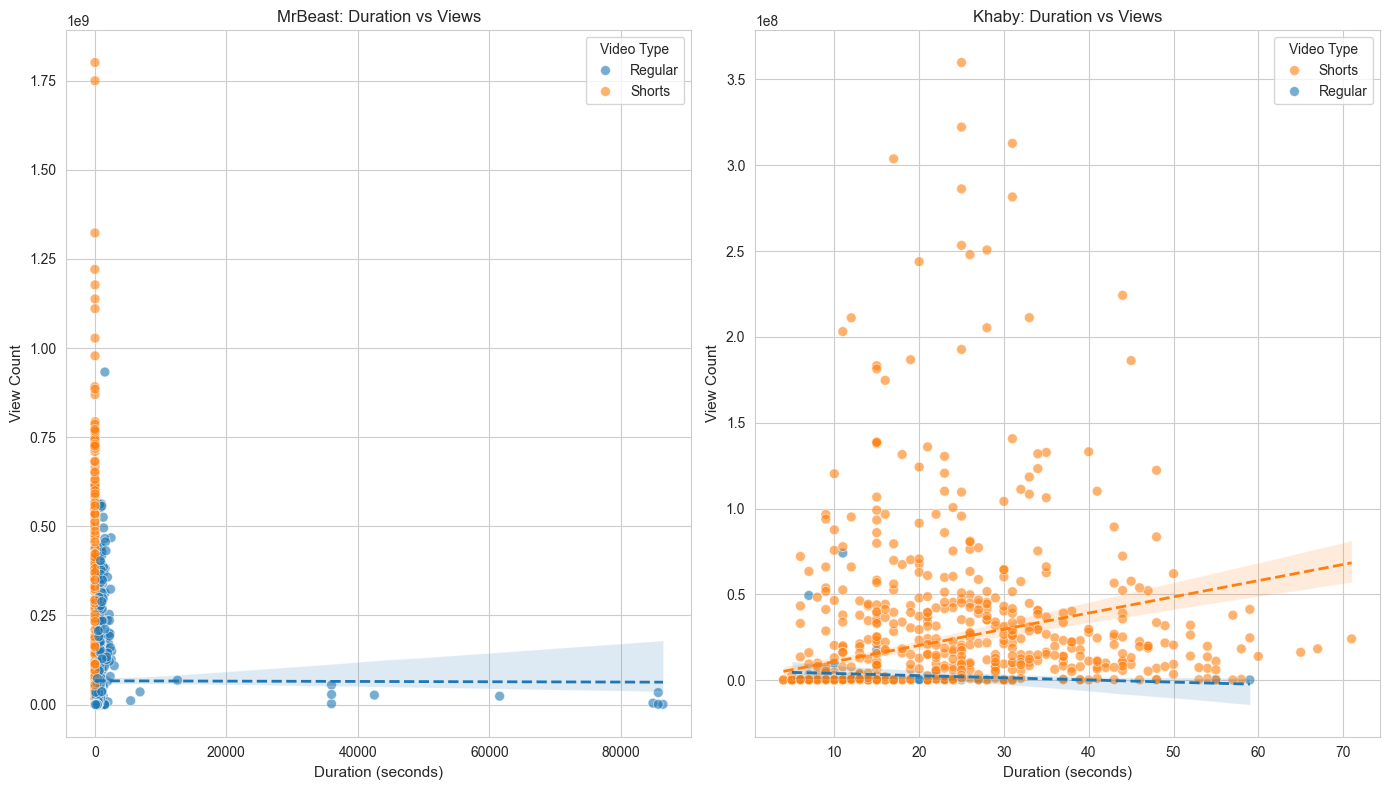

Summary Statistics


MrBeast:
  Regular:
    Count: 791
    Avg Duration: 1252.5s
    Avg Views: 66757292
  Shorts:
    Count: 182
    Avg Duration: 33.3s
    Avg Views: 395953169

Khaby:
  Regular:
    Count: 51
    Avg Duration: 14.6s
    Avg Views: 3383967
  Shorts:
    Count: 1032
    Avg Duration: 18.1s
    Avg Views: 18541884


In [18]:
# 6. 영상길이에 따른 조회수의 상관관계 
# 화면비가 1 이상인지 미만인지(>쇼츠 여부)로 hue를 구분해서 그려줘. sns를 적극적으로 활용하고
console.print(Markdown("# 6. 영상길이에 따른 조회수의 상관관계 (쇼츠 vs 일반영상)"))


def prepare_duration_views_data(df, name):
    """영상 길이와 조회수 데이터 준비 + 쇼츠 여부 분류"""
    # 필요한 컬럼만 선택
    df_plot = df[['duration', 'view_count', 'aspect_ratio']].dropna().copy()
    # 숫자로 변환
    df_plot['duration'] = pd.to_numeric(df_plot['duration'], errors='coerce')
    df_plot['view_count'] = pd.to_numeric(df_plot['view_count'], errors='coerce')
    df_plot['aspect_ratio'] = pd.to_numeric(df_plot['aspect_ratio'], errors='coerce')
    df_plot = df_plot.dropna()
    
    # 화면비로 영상 타입 분류
    # aspect_ratio >= 1: 일반영상 (가로 길이가 더 김)
    # aspect_ratio < 1: 쇼츠 (세로 길이가 더 김)
    df_plot['video_type'] = df_plot['aspect_ratio'].apply(
        lambda x: 'Regular' if x >= 1 else 'Shorts'
    )
    df_plot['channel'] = name
    return df_plot


# 데이터 준비
df_mrbeast_plot = prepare_duration_views_data(df_mrbeast, 'MrBeast')
df_khaby_plot = prepare_duration_views_data(df_khaby, 'Khaby')

# 두 데이터 합치기
# df_combined = pd.concat([df_mrbeast_plot, df_khaby_plot], ignore_index=True)

# ===== 채널별 그래프 그리기 =====
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for ax, (channel_name, df_channel) in zip(axes, [('MrBeast', df_mrbeast_plot), ('Khaby', df_khaby_plot)]):
    # Seaborn scatterplot: hue로 영상 타입 색상 구분
    sns.scatterplot(
        data=df_channel,
        x='duration',  # x축: 영상 길이
        y='view_count',  # y축: 조회수
        hue='video_type',  # 색상: 일반영상 vs 쇼츠
        palette={'Regular': '#1f77b4', 'Shorts': '#ff7f0e'},  # 색상 지정
        alpha=0.6,  # 투명도 (겹침 표시)
        s=50,  # 점 크기
        ax=ax
    )
    
    # 각 영상 타입별 추세선 추가 (회귀선으로 상관관계 파악)
    for video_type, color in [('Regular', '#1f77b4'), ('Shorts', '#ff7f0e')]:
        df_type = df_channel[df_channel['video_type'] == video_type]
        if len(df_type) > 1:
            # 회귀선만 표시 (scatter=False)
            sns.regplot(
                data=df_type,
                x='duration',
                y='view_count',
                scatter=False,
                line_kws={'color': color, 'linewidth': 2, 'linestyle': '--'},
                ax=ax
            )
    
    ax.set_xlabel('Duration (seconds)', fontsize=11)
    ax.set_ylabel('View Count', fontsize=11)
    ax.set_title(f'{channel_name}: Duration vs Views', fontsize=12)
    ax.legend(title='Video Type', loc='best')

plt.tight_layout()
plt.show()

# ===== 통계 요약 =====
console.print(Markdown("## Summary Statistics"))
for channel_name, df_channel in [('MrBeast', df_mrbeast_plot), ('Khaby', df_khaby_plot)]:
    print(f"\n{channel_name}:")
    # 일반영상과 쇼츠 비교
    for video_type in ['Regular', 'Shorts']:
        data = df_channel[df_channel['video_type'] == video_type]
        if len(data) > 0:
            print(f"  {video_type}:")
            print(f"    Count: {len(data)}")  # 개수
            print(f"    Avg Duration: {data['duration'].mean():.1f}s")  # 평균 길이
            print(f"    Avg Views: {data['view_count'].mean():.0f}")  # 평균 조회수
